# 🧩 Chương 2: Các Thành Phần Của Time Series (Decomposition)
## Advanced Data Science - Session 5

---

**Mục tiêu chương này:**
- Hiểu 4 thành phần cơ bản: Trend, Seasonality, Cyclic, Residual
- Phân biệt Additive vs Multiplicative decomposition
- Thực hành phân tích thành phần với Python
- Biết khi nào dùng mô hình nào

## 2.1 Tại Sao Cần Phân Tích Thành Phần?

### 🎯 Ví dụ minh họa:

Bạn là quản lý cửa hàng kem, nhìn vào doanh số:
- **Tháng 7:** Bán 10,000 ly → Vui!
- **Tháng 12:** Bán 3,000 ly → Buồn?

**❓ Câu hỏi:** Doanh số giảm vì:
- (A) Kinh doanh kém đi? → **Trend giảm**
- (B) Đang là mùa đông? → **Seasonality**
- (C) Cả hai?

→ **Decomposition** giúp tách biệt từng nguyên nhân để hiểu rõ!

### 📐 Công thức tổng quát:

```
Time Series = Trend + Seasonality + Cyclic + Residual
```

Giống như pha màu: 
- 🔴 Trend (xu hướng dài hạn)
- 🟢 Seasonality (mùa vụ lặp lại)
- 🔵 Cyclic (chu kỳ không cố định)
- ⚪ Residual (nhiễu ngẫu nhiên)

Trộn lại → 🟣 Time Series thực tế

## 2.2 Chi Tiết Từng Thành Phần

### A. 📈 Trend (Xu hướng)

**Định nghĩa:** Hướng di chuyển **dài hạn** của dữ liệu (tăng, giảm, hoặc phẳng)

**Ví dụ:**
- Dân số Việt Nam: Trend **tăng** qua các thập kỷ
- Số người dùng điện thoại bàn: Trend **giảm** do smartphone
- Nhiệt độ trái đất: Trend **tăng** nhẹ (global warming)

### B. 🔄 Seasonality (Tính mùa vụ)

**Định nghĩa:** Biến động lặp lại theo **chu kỳ cố định** và biết trước

**Ví dụ:**
- Doanh số kem: Tăng **mỗi mùa hè** (chu kỳ = 1 năm)
- Lưu lượng website: Tăng **mỗi thứ 2** (chu kỳ = 1 tuần)
- Tiêu thụ điện: Tăng **mỗi trưa** (chu kỳ = 1 ngày)

### C. 🌊 Cyclic (Chu kỳ)

**Định nghĩa:** Biến động theo chu kỳ **không cố định**, thường > 1 năm

**Khác biệt Seasonality vs Cyclic:**

| | Seasonality | Cyclic |
|---|---|---|
| Chu kỳ | Cố định (12 tháng, 7 ngày) | Không cố định |
| Biên độ | Thường không đổi | Có thể thay đổi |
| Dự đoán | Dễ | Khó |
| Ví dụ | Doanh số theo mùa | Chu kỳ kinh tế |

### D. 📡 Residual/Noise (Phần dư/Nhiễu)

**Định nghĩa:** Phần **không giải thích được** sau khi loại bỏ trend, seasonality, cyclic

**Ý nghĩa:**
- Residual nhỏ → Model giải thích tốt
- Residual có pattern → Model còn thiếu thông tin

## 2.3 Additive vs Multiplicative Model

### 🔢 Additive (Cộng):
```
Y(t) = T(t) + S(t) + R(t)
```
**Dùng khi:** Biên độ seasonality **không đổi** theo thời gian

Ví dụ: Doanh số dao động ±1000 mỗi mùa, dù trend tăng hay giảm

### ✖️ Multiplicative (Nhân):
```
Y(t) = T(t) × S(t) × R(t)
```
**Dùng khi:** Biên độ seasonality **tăng theo** trend

Ví dụ: Doanh số 100 → dao động ±10, doanh số 1000 → dao động ±100

### 🎯 Cách nhận biết:

Nhìn vào biểu đồ:
- Biên độ dao động **đều nhau** → Additive
- Biên độ dao động **tăng dần** (hình quạt) → Multiplicative

---
## 🔬 Phần Thực Hành
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print('✅ Import thành công!')

✅ Import thành công!


### 📝 Ví dụ 1: Tạo và Visualize Từng Thành Phần

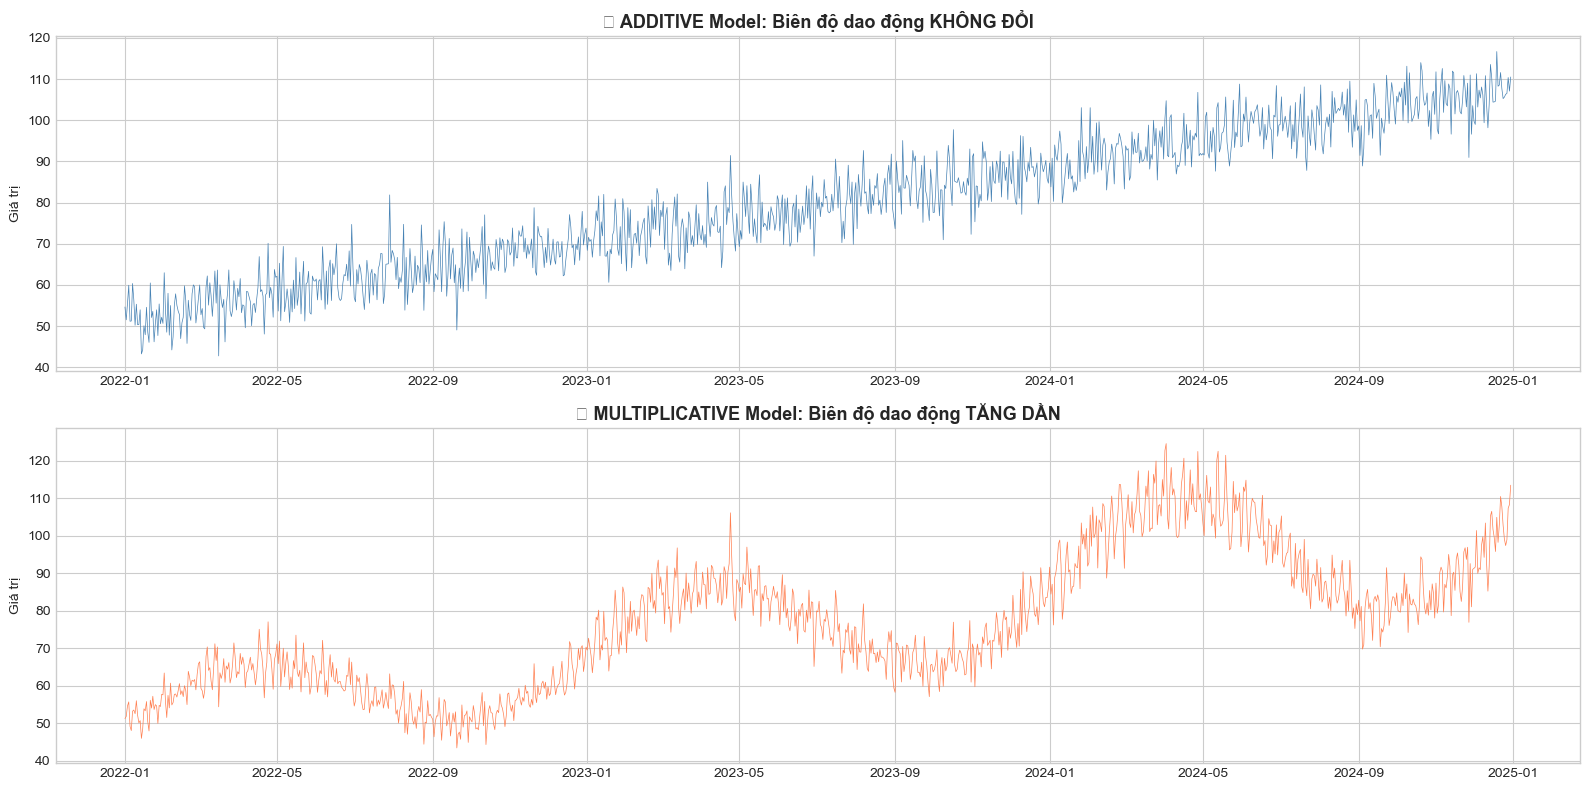

💡 Additive: Biên độ dao động đều → dùng model cộng
💡 Multiplicative: Biên độ tăng theo trend → dùng model nhân


In [2]:
# Tạo dữ liệu với các thành phần rõ ràng
np.random.seed(42)
n = 365 * 3  # 3 năm dữ liệu
dates = pd.date_range('2022-01-01', periods=n, freq='D')
t = np.arange(n)

# Từng thành phần
trend = 0.05 * t + 50                                    # Trend tăng tuyến tính
seasonality = 20 * np.sin(2 * np.pi * t / 365)           # Seasonality theo năm
weekly_season = 5 * np.sin(2 * np.pi * t / 7)            # Seasonality theo tuần
noise = np.random.normal(0, 5, n)                        # Nhiễu

seasonality_additive = 20 * np.sin(2 * np.pi * n / 365)
weekly_season_additive = 5 * np.sin(2 * np.pi * n / 7)          

# ADDITIVE: Cộng các thành phần
y_additive = trend + seasonality_additive + weekly_season_additive + noise

# MULTIPLICATIVE: Nhân các thành phần
y_multiplicative = trend * (1 + seasonality/100) * (1 + weekly_season/100) * (1 + noise/100)

# Tạo DataFrame
df_add = pd.DataFrame({'value': y_additive}, index=dates)
df_mul = pd.DataFrame({'value': y_multiplicative}, index=dates)

# Visualize sự khác biệt
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(df_add.index, df_add['value'], linewidth=0.5, color='steelblue')
axes[0].set_title('📊 ADDITIVE Model: Biên độ dao động KHÔNG ĐỔI', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Giá trị')

axes[1].plot(df_mul.index, df_mul['value'], linewidth=0.5, color='coral')
axes[1].set_title('📊 MULTIPLICATIVE Model: Biên độ dao động TĂNG DẦN', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Giá trị')

plt.tight_layout()
plt.show()

print('💡 Additive: Biên độ dao động đều → dùng model cộng')
print('💡 Multiplicative: Biên độ tăng theo trend → dùng model nhân')

### 📝 Ví dụ 2: Seasonal Decomposition với statsmodels

=== ADDITIVE DECOMPOSITION ===
Phân tách: Y = Trend + Seasonal + Residual



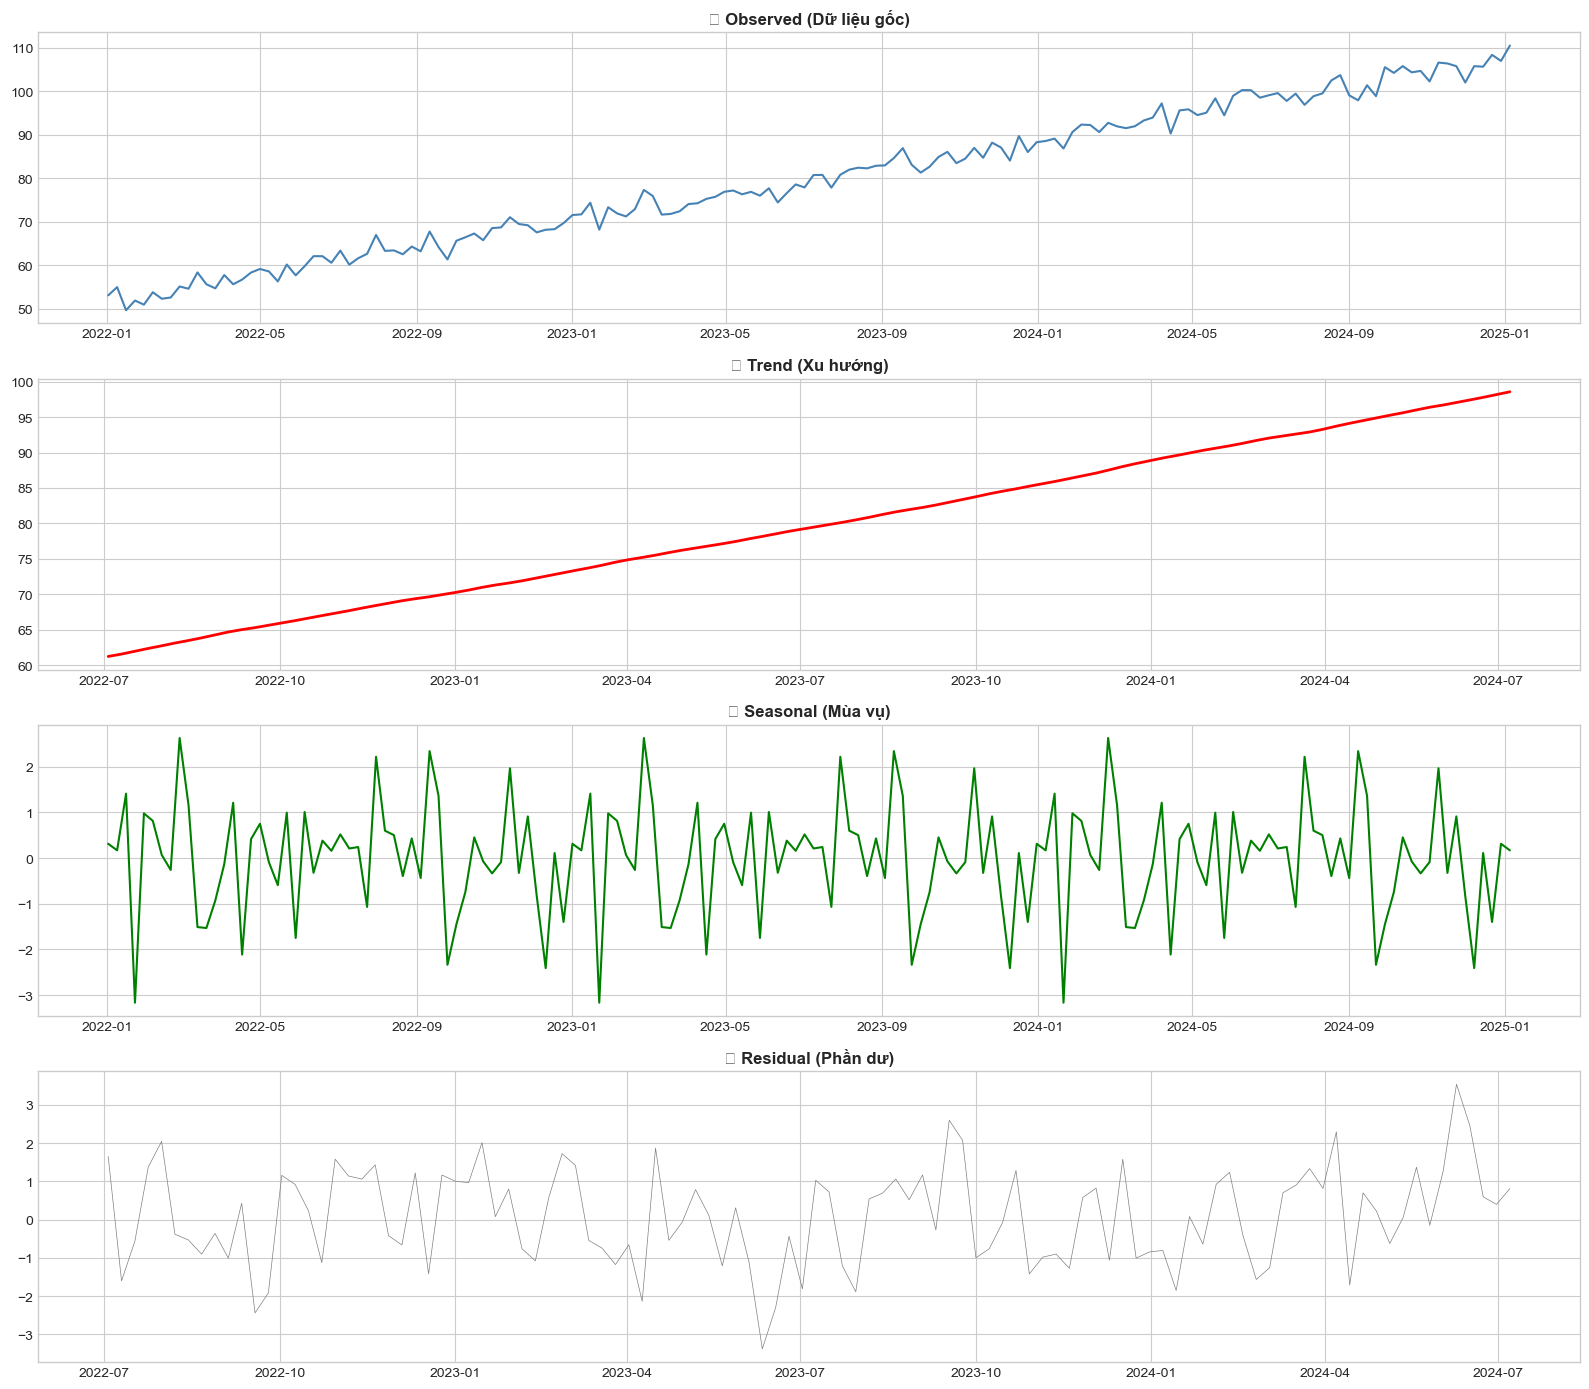


🔍 Phân tích:
  - Trend: Tăng dần từ ~50 lên ~100
  - Seasonal: Lặp lại mỗi năm, biên độ ~20
  - Residual: Dao động ngẫu nhiên quanh 0


In [3]:
# Additive Decomposition
print('=== ADDITIVE DECOMPOSITION ===')
print('Phân tách: Y = Trend + Seasonal + Residual\n')

# Resample theo tuần để giảm noise
df_weekly = df_add.resample('W').mean()

# Decompose
decomposition = seasonal_decompose(df_weekly['value'], model='additive', period=52)

# Visualize
fig, axes = plt.subplots(4, 1, figsize=(16, 14))

axes[0].plot(decomposition.observed, color='steelblue')
axes[0].set_title('📊 Observed (Dữ liệu gốc)', fontweight='bold')

axes[1].plot(decomposition.trend, color='red', linewidth=2)
axes[1].set_title('📈 Trend (Xu hướng)', fontweight='bold')

axes[2].plot(decomposition.seasonal, color='green')
axes[2].set_title('🔄 Seasonal (Mùa vụ)', fontweight='bold')

axes[3].plot(decomposition.resid, color='gray', linewidth=0.5)
axes[3].set_title('📡 Residual (Phần dư)', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n🔍 Phân tích:')
print('  - Trend: Tăng dần từ ~50 lên ~100')
print('  - Seasonal: Lặp lại mỗi năm, biên độ ~20')
print('  - Residual: Dao động ngẫu nhiên quanh 0')

### 📝 Ví dụ 3: So Sánh Additive vs Multiplicative Decomposition

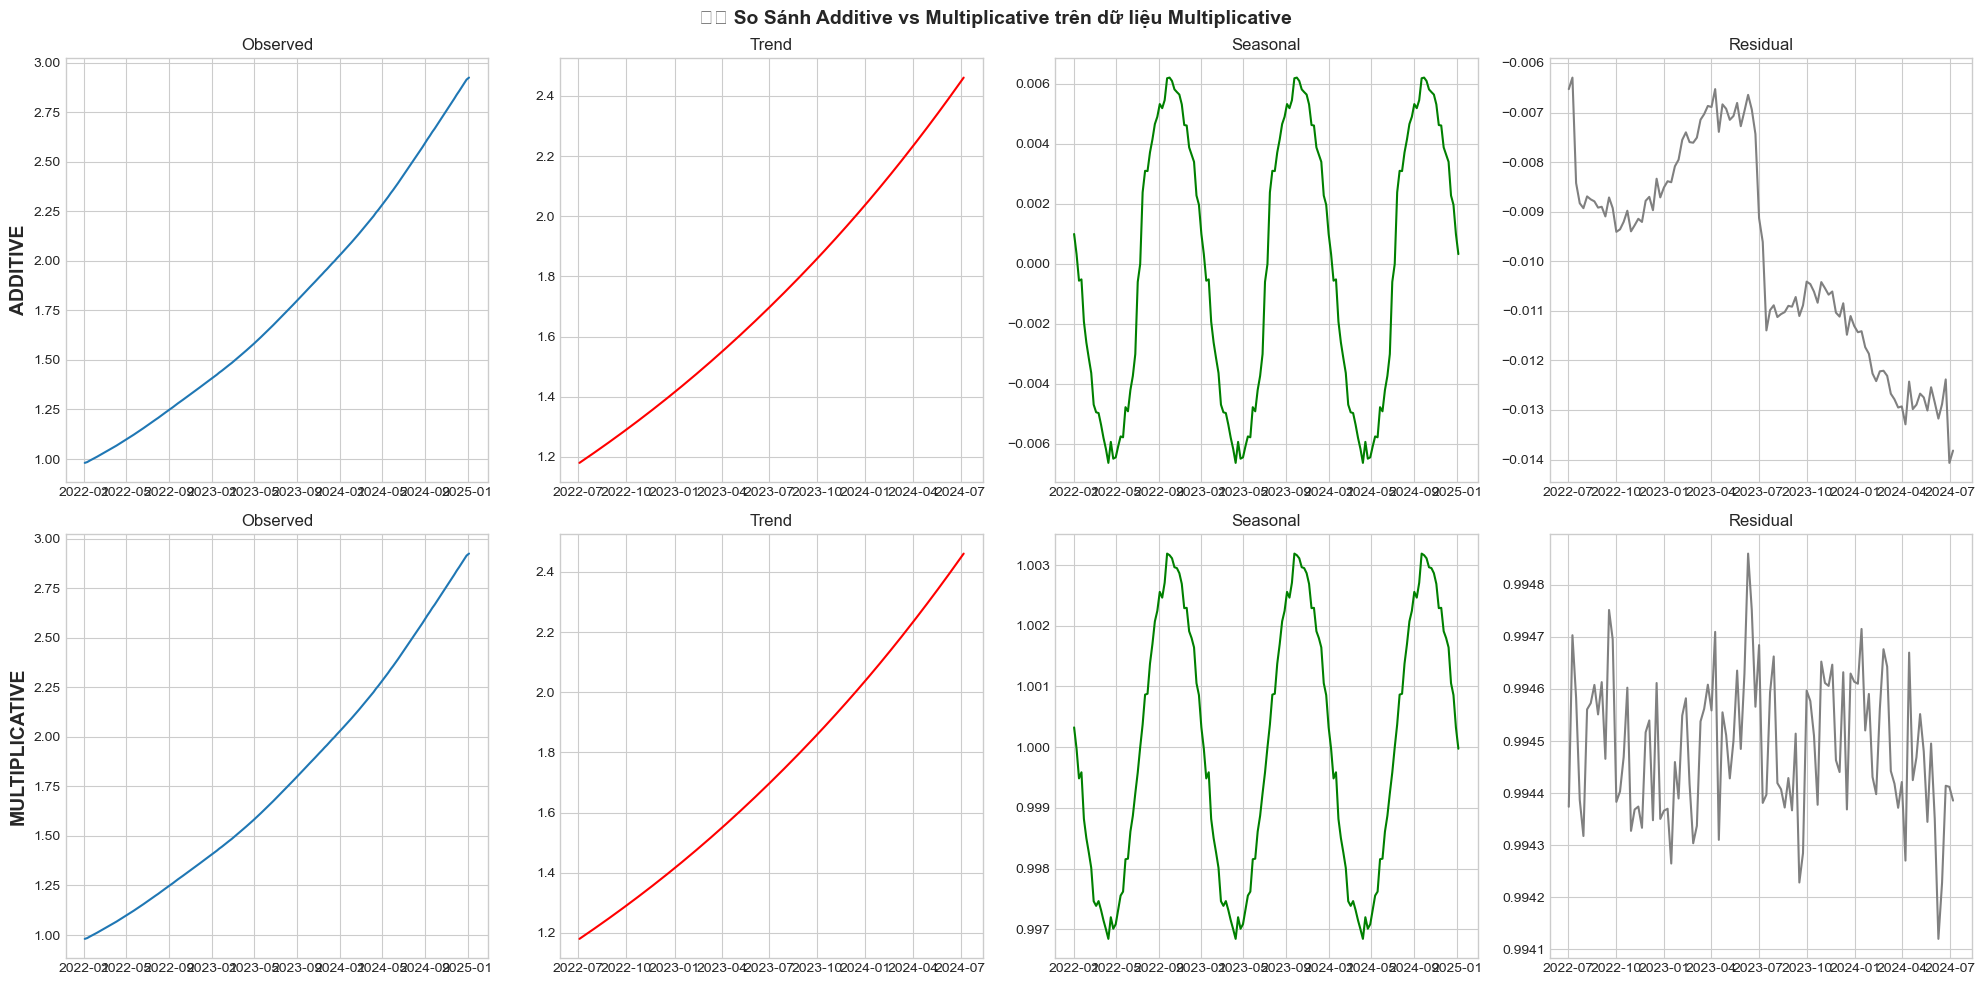


🔍 Nhận xét:
  - Additive: Residual vẫn còn pattern → KHÔNG PHÙ HỢP!
  - Multiplicative: Residual ~1.0, không có pattern → PHÙ HỢP!

💡 Mẹo: Nếu residual còn pattern → Thử đổi model!


In [4]:
# Tạo dữ liệu có tính multiplicative rõ ràng
np.random.seed(42)
n = 365 * 3
dates = pd.date_range('2022-01-01', periods=n, freq='D')
t = np.arange(n)

# Dữ liệu multiplicative: biên độ tăng theo thời gian
trend = np.exp(0.001 * t)  # Exponential growth
seasonal = 1 + 0.3 * np.sin(2 * np.pi * t / 365)  # ±30% seasonal
noise = 1 + np.random.normal(0, 0.05, n)
y_mul = trend * ( 1 - seasonal/100) * ( 1 - noise/100 ) 

df_mul = pd.DataFrame({'value': y_mul}, index=dates)
df_mul_weekly = df_mul.resample('W').mean()

# So sánh 2 kiểu decomposition trên cùng dữ liệu
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Additive
decomp_add = seasonal_decompose(df_mul_weekly['value'], model='additive', period=52)
axes[0, 0].plot(decomp_add.observed)
axes[0, 0].set_title('Observed')
axes[0, 1].plot(decomp_add.trend, color='red')
axes[0, 1].set_title('Trend')
axes[0, 2].plot(decomp_add.seasonal, color='green')
axes[0, 2].set_title('Seasonal')
axes[0, 3].plot(decomp_add.resid, color='gray')
axes[0, 3].set_title('Residual')
axes[0, 0].set_ylabel('ADDITIVE', fontweight='bold', fontsize=14)

# Multiplicative
decomp_mul = seasonal_decompose(df_mul_weekly['value'], model='multiplicative', period=52)
axes[1, 0].plot(decomp_mul.observed)
axes[1, 0].set_title('Observed')
axes[1, 1].plot(decomp_mul.trend, color='red')
axes[1, 1].set_title('Trend')
axes[1, 2].plot(decomp_mul.seasonal, color='green')
axes[1, 2].set_title('Seasonal')
axes[1, 3].plot(decomp_mul.resid, color='gray')
axes[1, 3].set_title('Residual')
axes[1, 0].set_ylabel('MULTIPLICATIVE', fontweight='bold', fontsize=14)

plt.suptitle('⚖️ So Sánh Additive vs Multiplicative trên dữ liệu Multiplicative', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🔍 Nhận xét:')
print('  - Additive: Residual vẫn còn pattern → KHÔNG PHÙ HỢP!')
print('  - Multiplicative: Residual ~1.0, không có pattern → PHÙ HỢP!')
print('\n💡 Mẹo: Nếu residual còn pattern → Thử đổi model!')

### 📝 Ví dụ 4: Phát Hiện Trend Bằng Moving Average

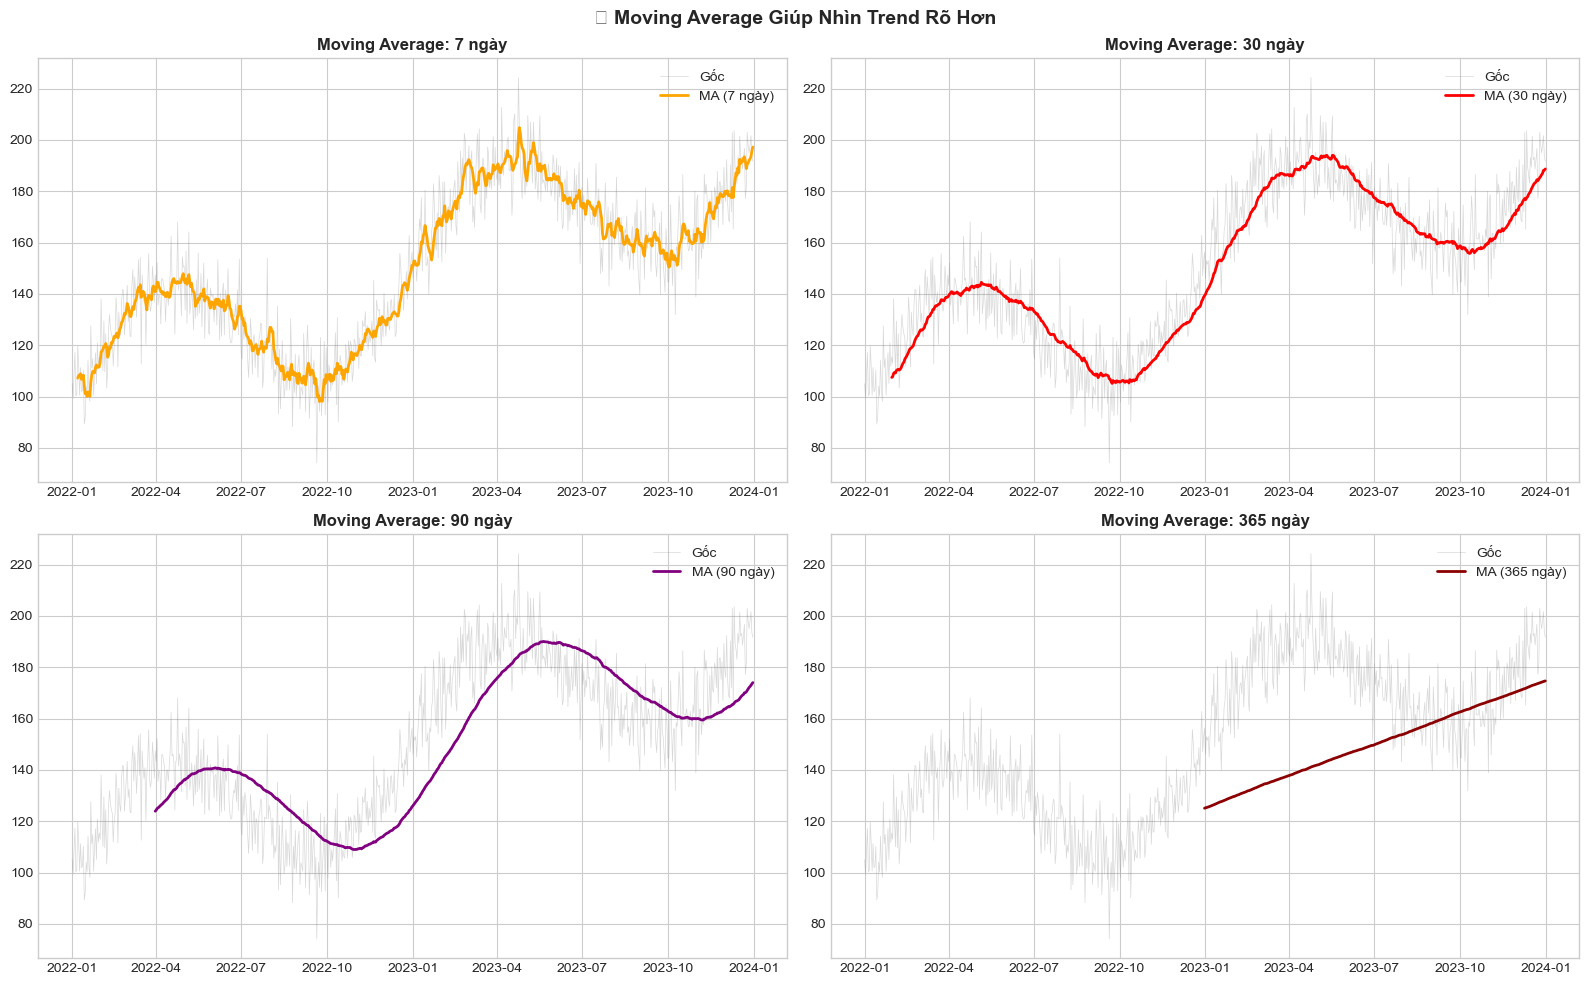

💡 Window càng lớn → Trend càng mượt → Nhưng mất nhiều data ở đầu
💡 MA(365) xóa hoàn toàn seasonality yearly → Chỉ còn trend thuần


In [5]:
# Moving Average để nhìn trend rõ hơn
np.random.seed(42)
dates = pd.date_range('2022-01-01', periods=730, freq='D')
trend = np.linspace(100, 200, 730)
#linspace tạo ra một mảng với các giá trị đều nhau từ 100 đến 200
seasonal = 30 * np.sin(2 * np.pi * np.arange(730) / 365)
noise = np.random.normal(0, 10, 730)
data = pd.Series(trend + seasonal + noise, index=dates, name='sales')

# Tính Moving Average với các window khác nhau
ma_7 = data.rolling(window=7).mean()   # 7 ngày
ma_30 = data.rolling(window=30).mean()  # 30 ngày
ma_90 = data.rolling(window=90).mean()  # 90 ngày
ma_365 = data.rolling(window=365).mean() # 365 ngày (xóa seasonality)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (ma, window, color) in zip(axes.flat, [
    (ma_7, '7 ngày', 'orange'),
    (ma_30, '30 ngày', 'red'),
    (ma_90, '90 ngày', 'purple'),
    (ma_365, '365 ngày', 'darkred')
]):
    ax.plot(data.index, data.values, alpha=0.3, color='gray', linewidth=0.5, label='Gốc')
    ax.plot(ma.index, ma.values, color=color, linewidth=2, label=f'MA ({window})')
    ax.set_title(f'Moving Average: {window}', fontweight='bold')
    ax.legend()

plt.suptitle('🔍 Moving Average Giúp Nhìn Trend Rõ Hơn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Window càng lớn → Trend càng mượt → Nhưng mất nhiều data ở đầu')
print('💡 MA(365) xóa hoàn toàn seasonality yearly → Chỉ còn trend thuần')

### 📝 Ví dụ 5: Phân Tích Strength of Trend and Seasonality

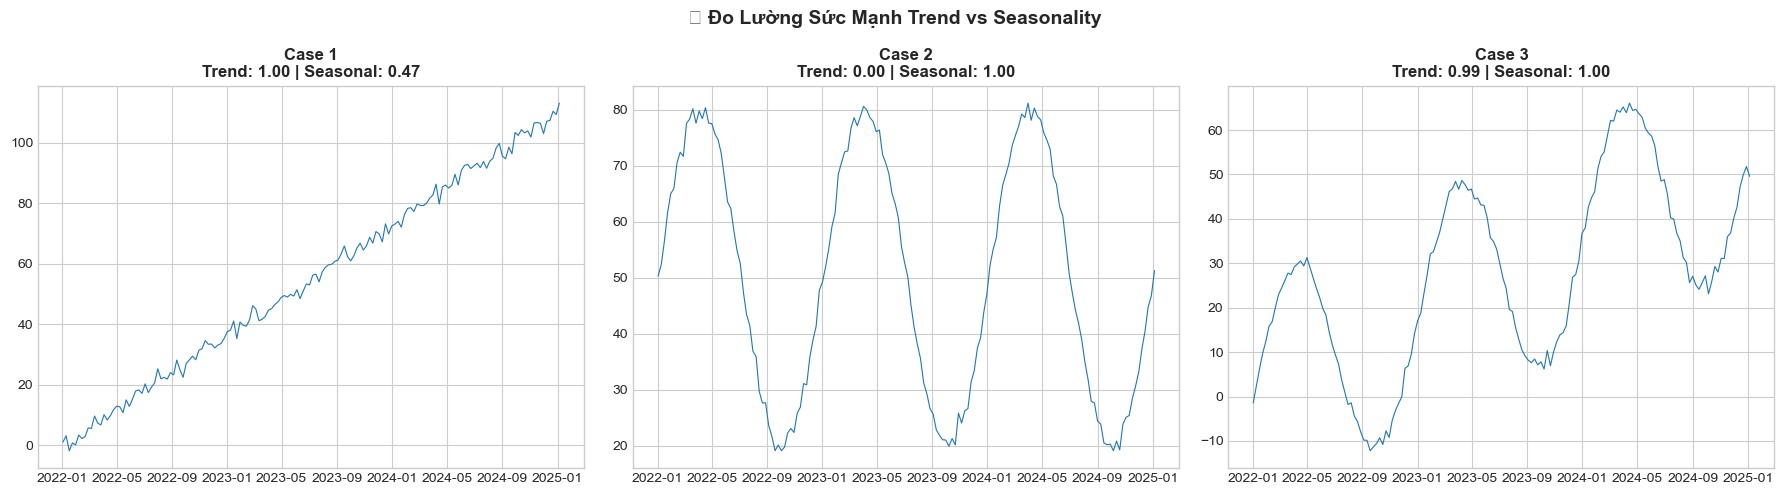

💡 Strength gần 1 → Thành phần đó rất mạnh
💡 Strength gần 0 → Thành phần đó rất yếu


In [6]:
# Đo lường mức độ mạnh/yếu của Trend và Seasonality

def measure_strength(data, period=52):
    """Đo lường sức mạnh của trend và seasonality"""
    decomp = seasonal_decompose(data, model='additive', period=period)
    
    # Variance
    var_resid = np.nanvar(decomp.resid)
    var_trend_resid = np.nanvar(decomp.trend + decomp.resid)
    var_season_resid = np.nanvar(decomp.seasonal + decomp.resid)
    
    # Strength
    trend_strength = max(0, 1 - var_resid / var_trend_resid)
    #Biến động của trend giải thích được bao nhiêu % so với tổng biến động 
    seasonal_strength = max(0, 1 - var_resid / var_season_resid)
    
    return trend_strength, seasonal_strength

# Tạo 3 loại dữ liệu khác nhau
np.random.seed(42)
n = 365 * 3
t = np.arange(n)
dates = pd.date_range('2022-01-01', periods=n, freq='D')

# Case 1: Trend mạnh, Seasonality yếu
y1 = 0.1 * t + np.random.normal(0, 5, n)
s1 = pd.Series(y1, index=dates).resample('W').mean()

# Case 2: Trend yếu, Seasonality mạnh
y2 = 50 + 30 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 3, n)
s2 = pd.Series(y2, index=dates).resample('W').mean()

# Case 3: Cả hai mạnh
y3 = 0.05 * t + 25 * np.sin(2 * np.pi * t / 365) + np.random.normal(0, 3, n)
s3 = pd.Series(y3, index=dates).resample('W').mean()

# Đo và hiển thị
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cases = [(s1, 'Case 1'), (s2, 'Case 2'), (s3, 'Case 3')]

for ax, (s, name) in zip(axes, cases):
    ts, ss = measure_strength(s, period=52)
    ax.plot(s.index, s.values, linewidth=0.8)
    ax.set_title(f'{name}\nTrend: {ts:.2f} | Seasonal: {ss:.2f}', fontweight='bold')

plt.suptitle('📊 Đo Lường Sức Mạnh Trend vs Seasonality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Strength gần 1 → Thành phần đó rất mạnh')
print('💡 Strength gần 0 → Thành phần đó rất yếu')

---
## 🏋️ BÀI TẬP THỰC HÀNH
---

### Bài 1: Nhận Biết Additive vs Multiplicative (⭐ Dễ)

Tạo 2 time series:
1. **Additive:** trend tuyến tính + seasonal biên độ cố định
2. **Multiplicative:** trend exponential + seasonal biên độ tăng theo trend

Plot cả 2 và giải thích sự khác biệt.

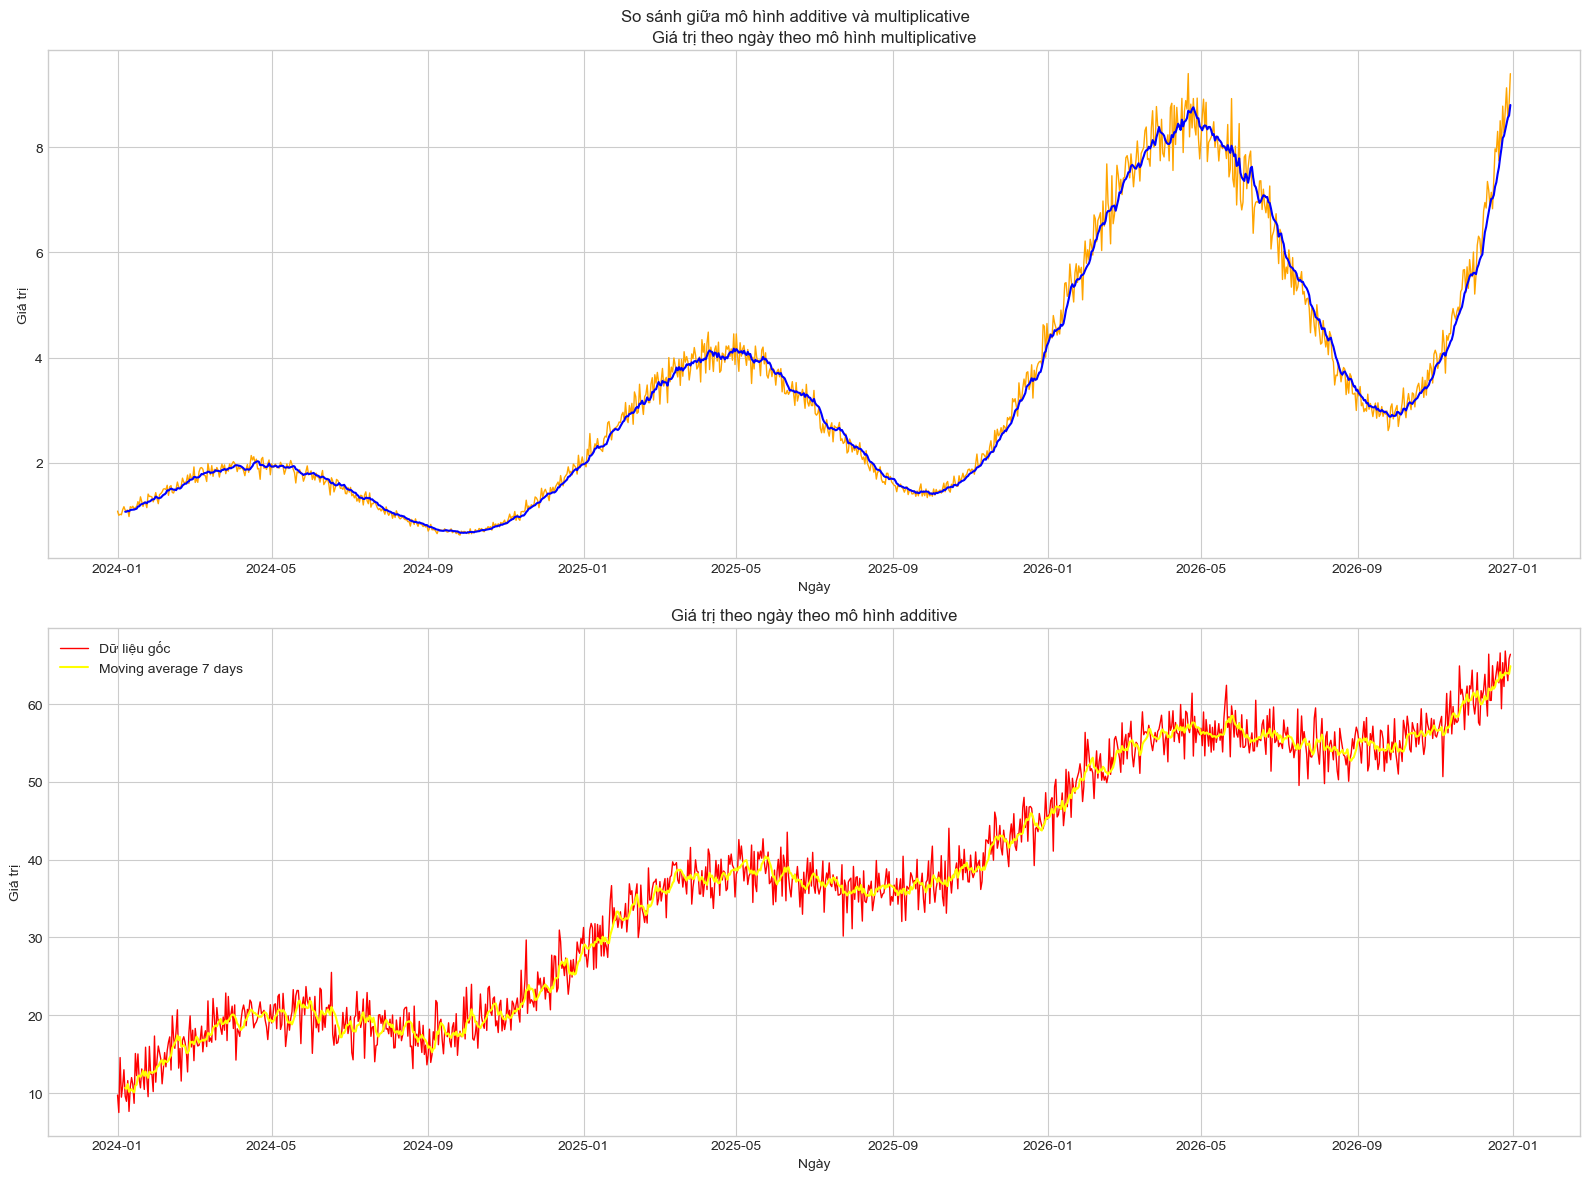

In [8]:
# TODO: Viết code ở đây
n = 365 * 3
t = np.arange(n)
dates = pd.date_range(start ='01-01-2024', freq = 'D', periods= n)

trend_mul = np.exp(0.002 * t)
seasonal_mul = 1 + 0.6 * np.sin(2 * np.pi * t / 365)
noise_mul = 1 + np.random.normal(0 , 0.05 , n )

multiplicative_model = trend_mul * seasonal_mul * noise_mul

trend_add = 0.05 * t + 10
seasonal_add = 5 * np.sin(2 * np.pi * t / 365) 
noise_add = np.random.normal(0, 2 , n )
additive_model = trend_add + seasonal_add + noise_add

mul_series = pd.Series( multiplicative_model , index = dates, name = 'value')
add_series = pd.Series( additive_model , index = dates, name = 'value')

moving_mul_avg_7 = mul_series.rolling(window = 7).mean()
moving_add_avg_7 = add_series.rolling(window = 7).mean()

fig , axes = plt.subplots(2, 1, figsize =(16,12))
axes[0].plot(mul_series.index , mul_series.values, color = 'orange', linewidth = 1, label ='Dữ liệu gốc')
axes[0].plot(moving_mul_avg_7.index , moving_mul_avg_7.values , color ='blue', linewidth = 1.5, label = 'Moving average 7 days')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Giá trị')
axes[0].set_title('Giá trị theo ngày theo mô hình multiplicative')

axes[1].plot(add_series.index , add_series.values, color = 'red', linewidth = 1, label = 'Dữ liệu gốc')
axes[1].plot(moving_add_avg_7.index , moving_add_avg_7.values , color ='yellow', linewidth = 1.5, label ='Moving average 7 days')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Giá trị')
axes[1].set_title('Giá trị theo ngày theo mô hình additive')

plt.suptitle('So sánh giữa mô hình additive và multiplicative')
plt.tight_layout()
plt.legend()
plt.show()

### Bài 2: Decomposition Thực Tế (⭐⭐ Trung bình)

Sử dụng file `retail_sales_dataset.csv`:
1. Đọc và xử lý dữ liệu (chuyển date, set index)
2. Resample theo tháng
3. Thực hiện cả **additive** và **multiplicative** decomposition
4. So sánh residual của 2 phương pháp
5. Kết luận nên dùng model nào?

 Trước khi xử lí 36 điểm dữ liệu
 Số giá trị <= 0:  0 


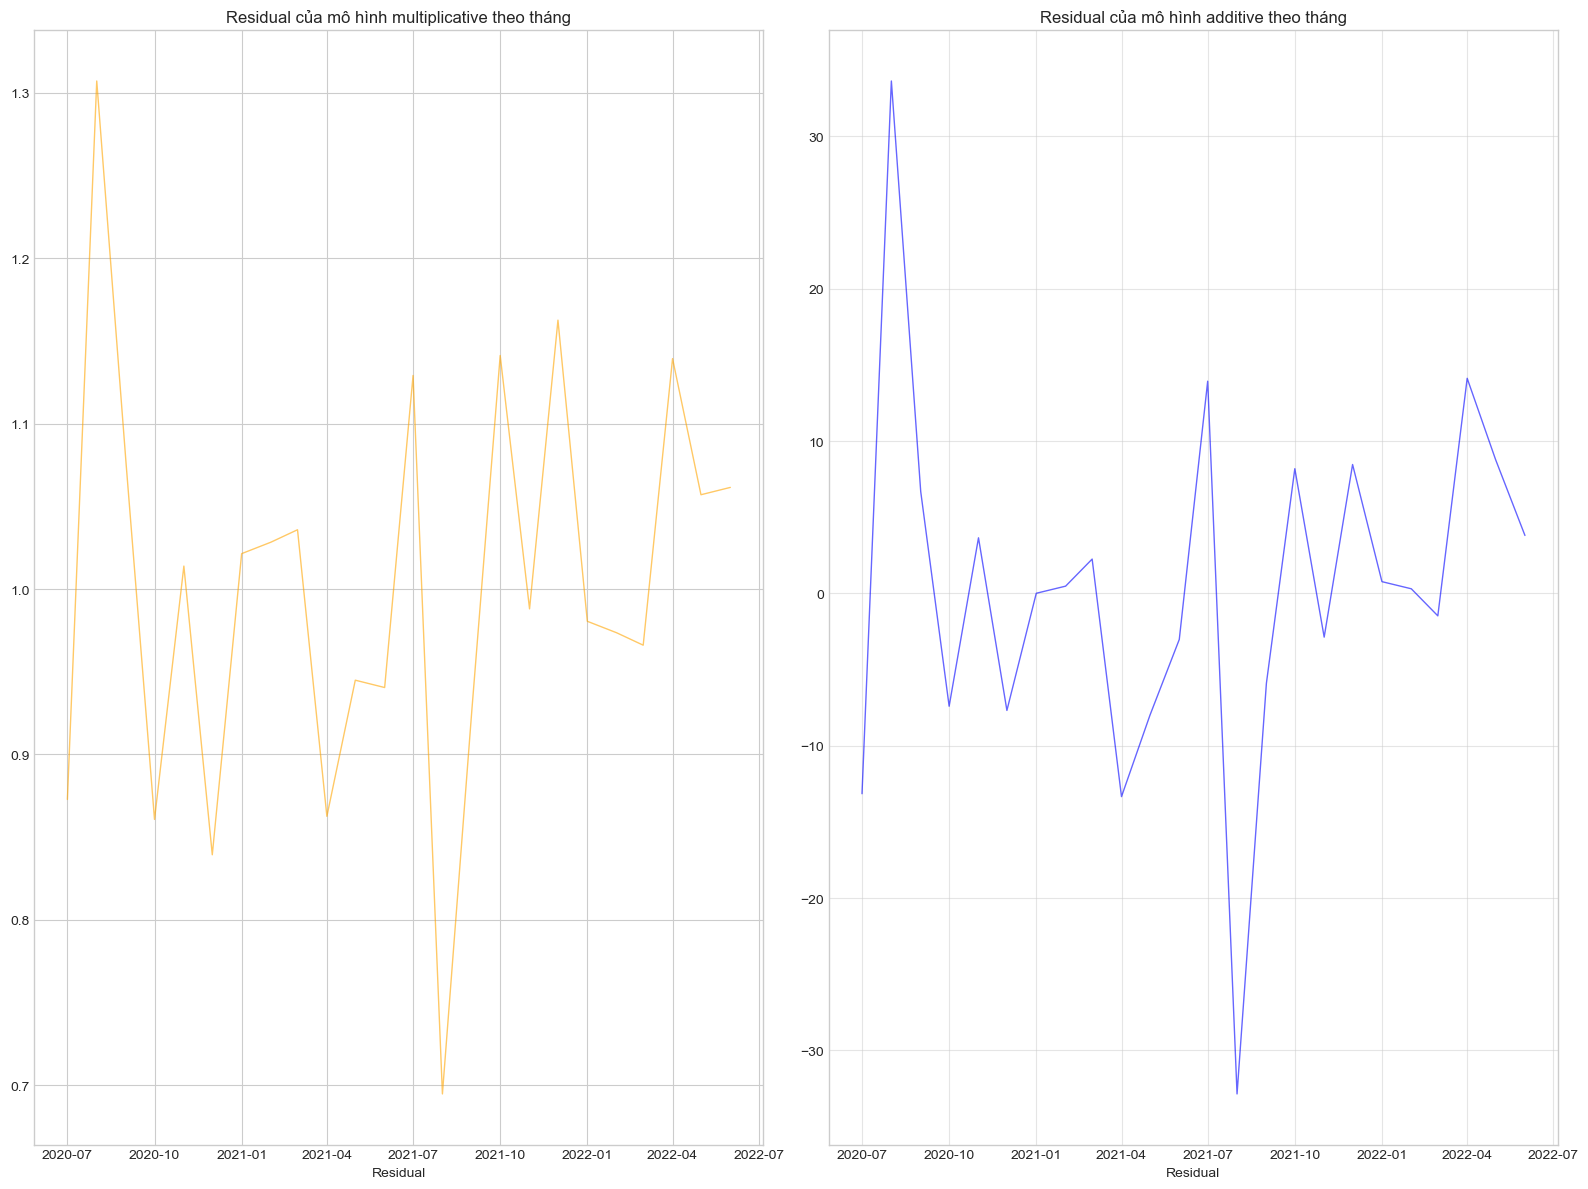


 Variance của multiplicative model : 0.015831902820908513 và additive model : 144.91632164580702

 Mean absoluate error của multiplicative model 0.096777148824377 và additive model : 8.366033224106141

 Skewnes của multiplicative model -6.531182901663717e-16 và additive model -8.689063480366383e-17

 số lượng outliers của multiplicative model 16 và additive model 23


In [9]:
# TODO: Viết code ở đây

retail_sale = pd.read_csv('../Bai thi thu/Course Files/retail_sales_dataset.csv', encoding = 'latin')

retail_sale.head()
retail_sale['date'] = pd.to_datetime(retail_sale['date'], errors ='coerce', dayfirst= True )
retail_sale = retail_sale.dropna(subset = ['date'])
retail_sale = retail_sale.set_index('date')
retail_sale.sort_index()

#Resample theo tháng 
Monthly_sale = retail_sale.resample('MS').mean()

target_cols = Monthly_sale.select_dtypes(include =[np.number]).columns[0]
cols_cleaned = Monthly_sale[target_cols].dropna().copy()
print(f" Trước khi xử lí {len(cols_cleaned)} điểm dữ liệu")
print(f" Số giá trị <= 0:  {(cols_cleaned <= 0).sum()} ")

#Thay thế các giá trị nhỏ hơn 0 bằng 1% giá trị nhỏ nhất 
min_positive = cols_cleaned[cols_cleaned > 0].min()
cols_cleaned[cols_cleaned < 0] = min_positive * 0.1


decompose_multiplicative = seasonal_decompose(cols_cleaned , model = 'multiplicative', period = 12)

decompose_additive= seasonal_decompose(cols_cleaned , model = 'additive', period = 12)

fig , axes = plt.subplots(1, 2 , figsize =(16,12))
axes[0].plot(cols_cleaned.index , decompose_multiplicative.resid , color ='orange', linewidth = 1, alpha = 0.6)
axes[0].set_xlabel('Tháng')
axes[0].set_xlabel('Residual')
axes[0].set_title('Residual của mô hình multiplicative theo tháng')

axes[1].plot(cols_cleaned.index , decompose_additive.resid , color ='blue', linewidth = 1, alpha = 0.6)
axes[1].set_xlabel('Tháng')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual của mô hình additive theo tháng')
plt.grid(alpha = 0.5) 
plt.tight_layout()
plt.legend()
plt.show()

var_mul = np.nanvar(decompose_multiplicative.resid)
var_add = np.nanvar(decompose_additive.resid)

mae_mul = np.nanmean(np.abs(decompose_multiplicative.resid - 1.0)) 
mae_add = np.nanmean(np.abs(decompose_additive.resid))

from scipy.stats import skew
skew_mul = skew(decompose_multiplicative.resid.dropna())
skew_add = skew(decompose_additive.resid.dropna())

print(f"\n Variance của multiplicative model : {var_mul} và additive model : {var_add}")
print(f"\n Mean absoluate error của multiplicative model {mae_mul} và additive model : {mae_add}")
print(f"\n Skewnes của multiplicative model {skew_mul} và additive model {skew_add}")

#Số lượng residual vượt ngưỡng outlier 
thresold_mul = 0.05 # +- 5% từ 1.0 
thresold_add = 0.1 #+- 0.1 std 

outliers_mul = np.sum(np.abs(decompose_multiplicative.resid - 1.0) > thresold_mul) 
outliers_add = np.sum(np.abs(decompose_additive.resid) > thresold_add)

print(f"\n số lượng outliers của multiplicative model {outliers_mul} và additive model {outliers_add}")

### Bài 3: Moving Average vs Decomposition (⭐⭐ Trung bình)

Với dữ liệu giả lập (hoặc thực tế):
1. Tính Moving Average với window = 7, 30, 90, 365
2. Dùng `seasonal_decompose` để lấy trend
3. So sánh: MA(365) với Trend từ decompose có giống nhau không?
4. Tính correlation giữa 2 đường trend

📊 KIỂM TRA DỮ LIỆU TRƯỚC KHI DECOMPOSE:
   - Số điểm dữ liệu: 369
   - Số giá trị NaN: 0
   - Số giá trị ≤ 0: 0
   - Min: 0.01, Max: 542.00


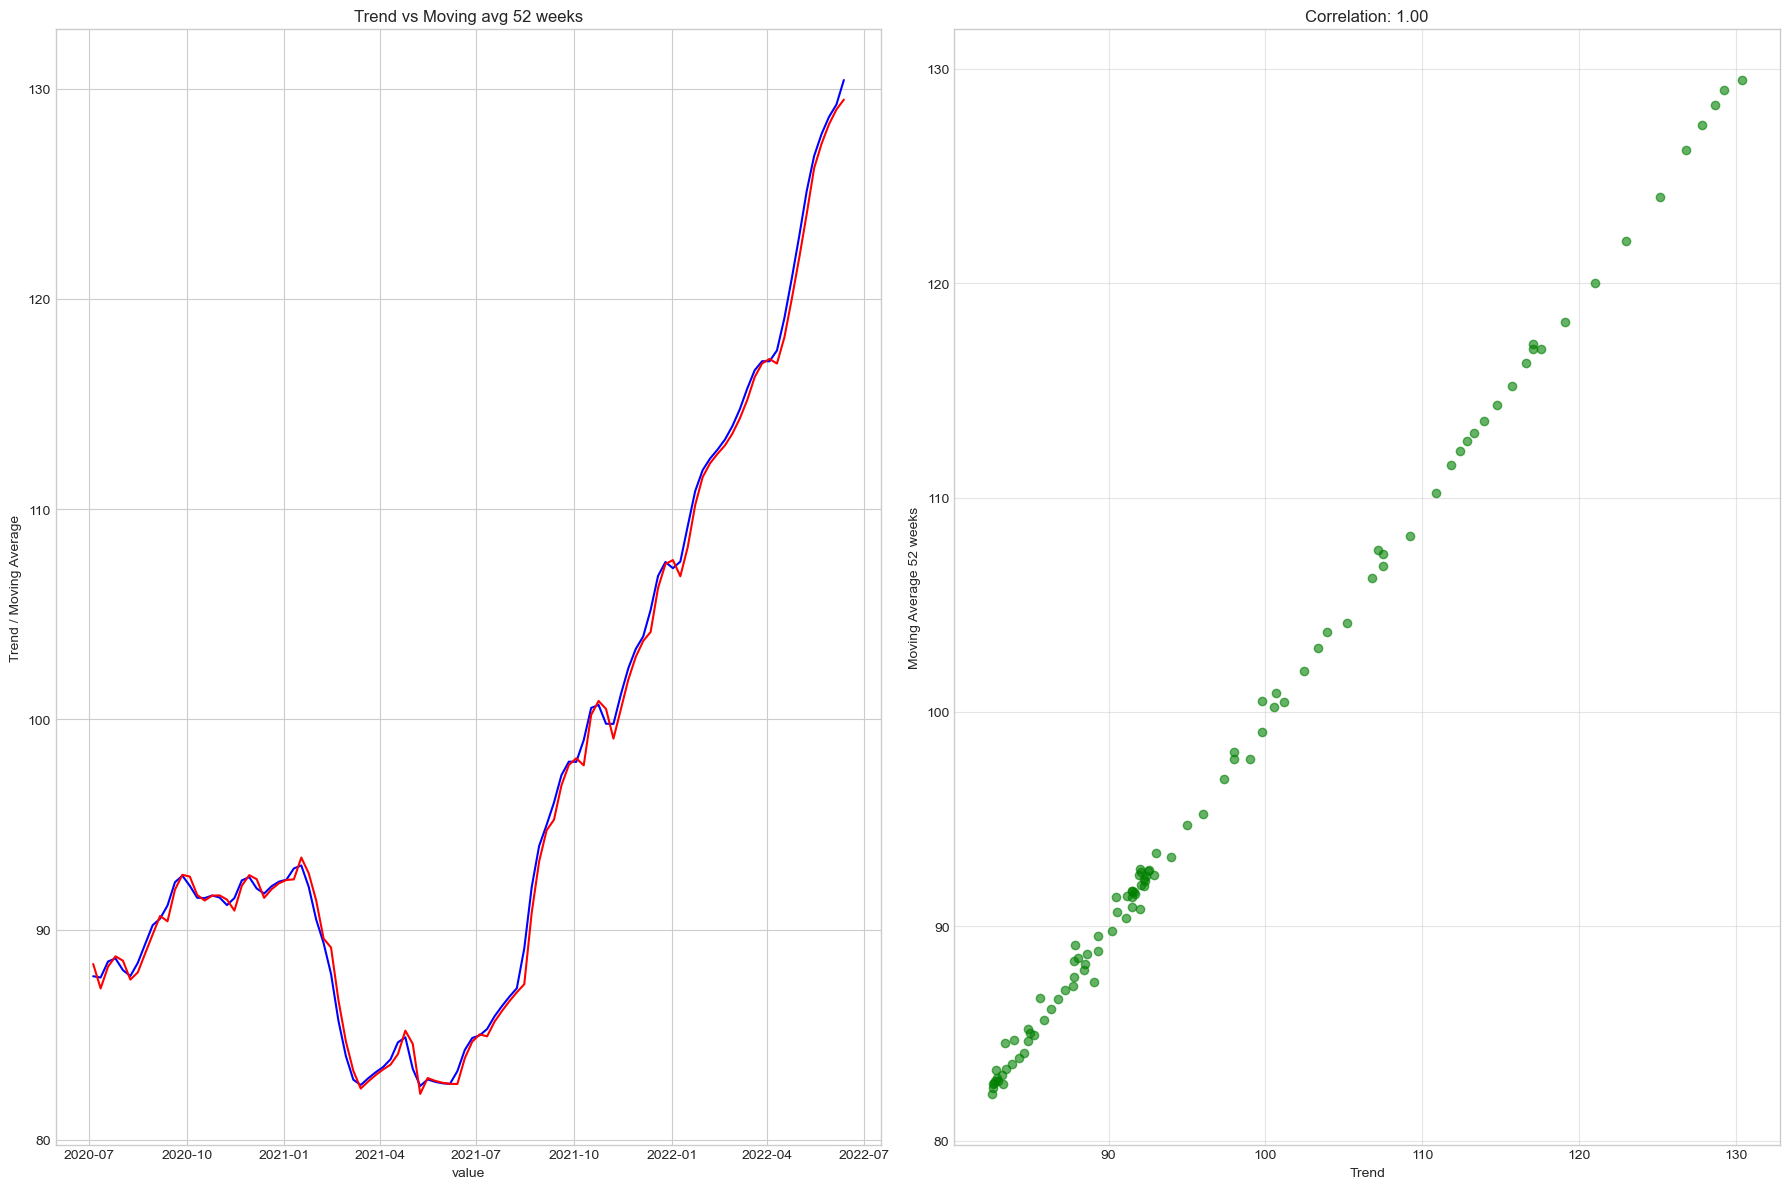

In [18]:


target_cols_2 = retail_sale.select_dtypes(include = [np.number]).columns[0]
data_cleaned = retail_sale[target_cols_2].dropna().copy()
min_positive_2 = data_cleaned[data_cleaned > 0].min()
data_cleaned = data_cleaned.astype(float)
data_cleaned[data_cleaned <= 0 ] = min_positive_2 * 0.01



print('📊 KIỂM TRA DỮ LIỆU TRƯỚC KHI DECOMPOSE:')
print(f'   - Số điểm dữ liệu: {len(data_cleaned)}')
print(f'   - Số giá trị NaN: {data_cleaned.isna().sum()}')
print(f'   - Số giá trị ≤ 0: {(data_cleaned <= 0).sum()}')
print(f'   - Min: {data_cleaned.min():.2f}, Max: {data_cleaned.max():.2f}')
#Có thể data không đủ 104 tuần nên resample theo tuần để có đủ data cho decomposition


data_weekly = data_cleaned.resample('W').mean()
data_weekly = data_weekly.interpolate(method = 'linear') #Điền giá trị NaN bằng nội suy tuyến tính
#Nội suy tuyến tính là một phương pháp đơn giản để điền giá trị thiếu bằng cách sử dụng giá trị trước và sau đó để tính toán giá trị trung bình tuyến tính. Điều này giúp đảm bảo rằng dữ liệu không bị gián đoạn và có thể được sử dụng cho phân tích tiếp theo.
data_weekly = data_weekly.fillna(method = 'bfill').fillna(method = 'ffill') #Điền giá trị NaN còn lại bằng phương pháp backfill và forward fill
#Phương pháp backfill sẽ điền giá trị NaN bằng giá trị tiếp theo trong chuỗi thời gian. Điều này đảm bảo rằng nếu có bất kỳ giá trị NaN nào còn lại sau khi nội suy tuyến tính, chúng sẽ được điền bằng giá trị tiếp theo, giúp duy trì tính liên tục của dữ liệu.
#forward fill sẽ điền giá trị NaN bằng giá trị trước đó trong chuỗi thời gian. Điều này đảm bảo rằng nếu có bất kỳ giá trị NaN nào còn lại sau khi nội suy tuyến tính, chúng sẽ được điền bằng giá trị trước đó, giúp duy trì tính liên tục của dữ liệu.


decompose = seasonal_decompose(data_weekly, period = 52 , model = 'multiplicative')
trend = decompose.trend

moving_avg_52w = data_weekly.rolling(window = 52 , center = True).mean()
#Align index between trend and ma 52 weeks

common_index = trend.dropna().index.intersection(moving_avg_52w.dropna().index)
trend_aligned = trend.loc[common_index]
moving_avg_52w_aligned = moving_avg_52w.loc[common_index]

#phải align index vì trend và moving average có thể có giá trị NaN ở các vị trí khác nhau
correlation = trend_aligned.corr(moving_avg_52w_aligned)


fig, axes = plt.subplots(1,2 , figsize =(18,12))

axes[0].plot(trend_aligned.index , trend_aligned.values, color = 'blue', linewidth = 1.5 , label = 'Trend')
axes[0].plot(moving_avg_52w_aligned.index , moving_avg_52w_aligned.values, color = 'red', linewidth = 1.5 , label = 'Moving Average 52 weeks')
axes[0].set_xlabel('value')
axes[0].set_ylabel('Trend / Moving Average')
axes[0].set_title('Trend vs Moving avg 52 weeks')
#plot correlation 
axes[1].scatter(trend_aligned.values , moving_avg_52w_aligned.values , color = 'green', alpha = 0.6)
axes[1].set_xlabel('Trend')
axes[1].set_ylabel('Moving Average 52 weeks')
axes[1].set_title(f'Correlation: {correlation:.2f}')
plt.grid(alpha = 0.5)
plt.tight_layout()
plt.legend()
plt.show()


### Bài 4: Phân Tích Thành Phần Nâng Cao (⭐⭐⭐ Nâng cao)

Đọc file `stores_sales_forecasting.csv`:
1. Chọn một cột doanh số và decompose
2. Tính **trend strength** và **seasonal strength**
3. Xác định seasonal period (theo tuần? tháng? quý?)
4. Thử decompose với các period khác nhau và so sánh
5. Vẽ heatmap doanh số theo tháng × năm để thấy seasonality

In [ ]:
# TODO: Viết code ở đây

---
# 🧠 PHẦN ÔN TẬP & CỦNG CỐ KIẾN THỨC - CHƯƠNG 2

---

## 1️⃣ Nguyên Lí 80/20: 20% Kiến Thức Cốt Lõi Mang Lại 80% Giá Trị

> **Nếu bạn chỉ nhớ được 3 điều từ chương này, hãy nhớ:**

### 🔑 Kiến thức #1: Time Series = Trend + Seasonality + Residual
- Mọi chuỗi thời gian đều có thể **tách ra** thành các thành phần riêng biệt
- **Trend** = Hướng đi dài hạn (tăng/giảm/phẳng)
- **Seasonality** = Pattern lặp lại theo chu kỳ cố định
- **Residual** = Phần nhiễu không giải thích được

### 🔑 Kiến thức #2: Additive vs Multiplicative — Chọn đúng mô hình
- **Additive** khi biên độ seasonal **KHÔNG ĐỔI** theo level: `Y = T + S + R`
- **Multiplicative** khi biên độ seasonal **TĂNG/GIẢM** theo level: `Y = T × S × R`
- **Mẹo nhanh:** Nhìn đồ thị → Biên độ dao động lớn dần theo thời gian? → **Multiplicative**

### 🔑 Kiến thức #3: `seasonal_decompose()` — Công cụ một dòng code
```python
from statsmodels.tsa.seasonal import seasonal_decompose

# Một dòng code giải quyết tất cả:
result = seasonal_decompose(data, model='additive', period=12)
result.plot()  # Tách thành 4 biểu đồ rõ ràng
```

> **Một câu tóm tắt:** *"Decomposition = tách cocktail thành từng nguyên liệu: nước cốt (Trend), đá (Seasonality), và vụn (Residual)."*

---

## 2️⃣ Mô Hình Hóa Kiến Thức: Phép Ẩn Dụ "Công Thức Nấu Ăn"

### 🍲 Câu chuyện: Decomposition giống như TÁCH MÓN PHỞ thành nguyên liệu

Hãy tưởng tượng bạn ăn một **tô phở** ngon tuyệt vời:

```
🍜 Tô phở hoàn chỉnh = Time Series thực tế
```

Bạn muốn biết **tại sao nó ngon?** → Bạn cần **TÁCH** ra:

| Nguyên liệu Phở | → Thành phần Time Series |
|---|---|
| 🥩 **Nước dùng** (nền tảng, quyết định hương vị chính) | **Trend** — xu hướng dài hạn, "nền tảng" của dữ liệu |
| 🌿 **Rau thơm** (thêm vào theo mùa: húng, ngò) | **Seasonality** — biến động lặp lại theo chu kỳ |
| 🌊 **Chu kỳ kinh tế** (giá thịt lên/xuống bất thường) | **Cyclic** — chu kỳ không cố định |
| 🧂 **Muối/Gia vị nhỏ** (khó đo chính xác) | **Residual** — nhiễu ngẫu nhiên |

**Additive vs Multiplicative:**
- **Additive (Phở bình dân):** Mỗi nguyên liệu thêm một lượng **cố định** → Mọi tô đều giống nhau
- **Multiplicative (Phở buffet):** Tô lớn hơn → mọi thứ **nhân lên** tỷ lệ → Biên độ tăng theo kích thước

### 🎨 Sơ đồ tư duy:
```
              TIME SERIES (Tô phở)
                      │
          ┌───────────┼───────────┐
          │           │           │
    📈 TREND    🔄 SEASONALITY  📡 RESIDUAL
    (Nước dùng)  (Rau theo mùa)  (Gia vị nhỏ)
          │           │           │
     Dài hạn     Chu kỳ cố     Ngẫu nhiên
     Tăng/Giảm   định (12th,   Không dự đoán
     /Phẳng      7 ngày...)     được
          │
    ┌─────┴─────┐
    │           │
 Additive   Multiplicative
 Y=T+S+R    Y=T×S×R
 (biên độ    (biên độ
  không đổi)  tỷ lệ)
```

---

## 3️⃣ Liên Tưởng Với Cuộc Sống

### 🏪 Doanh số cửa hàng kem
- **Trend:** Năm sau bán nhiều hơn năm trước (vì dân số tăng, thương hiệu lớn hơn)
- **Seasonality:** Mùa hè bán 3x mùa đông → Pattern lặp lại **mỗi năm**
- **Residual:** Hôm nay mưa bất chợt → Bán ít hơn bình thường (không dự đoán được)
- **Loại:** Multiplicative! Vì năm 2020 mùa hè bán +500 ly, năm 2024 bán +2000 ly (tỷ lệ với doanh số tổng)

### 📊 Điểm số học tập của bạn
- **Trend:** Điểm tăng dần qua các kỳ (vì bạn học giỏi hơn)
- **Seasonality:** Điểm cuối kỳ thường thấp hơn giữa kỳ (nhiều áp lực/khó hơn) → Chu kỳ 1 học kỳ
- **Residual:** Hôm thi bị ốm → Điểm thấp bất thường

### 💵 Tiền lương của một người
- **Trend:** Lương tăng dần qua các năm (thăng chức, lạm phát)
- **Seasonality:** Tháng 12, tháng 1 lương nhiều hơn (thưởng Tết, bonus)
- **Cyclic:** Kinh tế suy thoái vài năm một lần → Lương có thể bị giảm/đứng
- **Loại:** Multiplicative (Bonus 1 tháng lương: lương 10tr → bonus 10tr, lương 30tr → bonus 30tr)

### 🚇 Lượng hành khách tàu điện
- **Trend:** Tăng mỗi năm khi nhiều người chuyển sang phương tiện công cộng
- **Seasonality:** Giờ cao điểm sáng/chiều đông hơn → Chu kỳ 1 ngày
- **Residual:** Ngày lễ bất thường → Ít hành khách

---

## 4️⃣ Teach to Learn — Giảng Lại Để Hiểu Sâu

### 📝 Bài tập 1: Giải thích Decomposition cho "người không biết gì"
> Tưởng tượng bạn đang giải thích cho **bạn cùng phòng** không học IT.
> Dùng ví dụ về **doanh số quán cà phê** gần nhà để giải thích 4 thành phần.

In [ ]:
# ✍️ BÀI TẬP 1: Giải thích Decomposition cho bạn cùng phòng (không học IT)
# Dùng ví dụ doanh số quán cà phê gần nhà để giải thích 4 thành phần

"""
Viết câu trả lời ở đây:

Trend của quán cà phê là: Doanh số cà phê tăng dần vì quán đang ngày càng nổi tiếng và có nhiều món đa dạng và ngon hơn 
Seasonality là: doanh số tăng mạnh vào dịp tết vì lúc này nhiều người đi cà phê , và biên độ dao động cũng thay đổi theo doanh số quán cà phê vì khi quán càng nổi tiếng thì vào dịp tết lượng khách hàng sẽ tăng đột biến hơn 
Cyclic là: doanh số tăng mạnh vào dịp tết nhưng sau đó lại xảy ra dịch bệnh khiến lượng người đi cà phê ít hơn hẳn , dịch bệnh này khó dự đoán được nếu chỉ dựa vào doanh số cà phê , có thể dịch bệnh lại thuộc thành phần seasonality của một chu kì kinh tế lớn hơn 
Residual là: Nhiễu , vì dụ nếu một ngày nào đó tự nhiên có mưa lớn thì lượng khách hàng giảm 

Tại sao cần tách ra? Để phân tích nguyên nhân của sự thay đổi doanh số , có phải là do tính chất thất thường của cyclic , hay sự nhiễu nhỏ , hay thay đổi tùy vào thởi điểm mùa vụ , hay là thay đổi dựa trên xu hướng dài hạn của doanh số 
"""

In [ ]:
# ✍️ BÀI TẬP 2: Chọn Additive hay Multiplicative?
# Cho 3 tình huống, chọn model phù hợp và GIẢI THÍCH TẠI SAO

"""
Tình huống 1: Số khách du lịch Đà Nẵng 
  (tăng mạnh qua từng năm, mùa hè đông gấp 5 lần mùa đông)
  → Chọn: _______________
  → Lý do: _______________

Tình huống 2: Nhiệt độ Hà Nội mỗi ngày 
  (dao động quanh 25°C, mùa hè +10°C, mùa đông -10°C)
  → Chọn: _______________
  → Lý do: _______________

Tình huống 3: Doanh thu quảng cáo Facebook 
  (tăng nhanh, biến động cuối năm ngày càng lớn)
  → Chọn: _______________
  → Lý do: _______________
"""

In [ ]:
# ✍️ BÀI TẬP 3: Tự tạo ví dụ từ cuộc sống và phân tích
# Nghĩ ra 1 ví dụ time series và viết phân tích đầy đủ

"""
Ví dụ của tôi: _______________

Trend là gì? _______________
Seasonality là gì? Chu kỳ bao lâu? _______________
Tôi chọn Additive/Multiplicative vì: _______________
Cách decompose: _______________

Viết code decompose (nếu có data):
"""

# import pandas as pd
# from statsmodels.tsa.seasonal import seasonal_decompose
# 
# # Tạo data mẫu cho ví dụ của bạn
# # data = ...
# # result = seasonal_decompose(data, model='additive', period=?)
# # result.plot()